In [ ]:
# Student Performance Prediction Using Linear Regression

### Mini Project – Supervised Learning Using Python

**Project Type:** Individual Mini Project  
**Programming Language:** Python  
**Machine Learning Technique:** Linear Regression  
**Target Variable:** Final Score

In [ ]:
## 1. Problem Statement

Student performance can be influenced by several academic and lifestyle-related factors. The objective of this project is to analyze student data and develop a supervised machine learning model to predict students' final scores using selected factors such as study hours, attendance, previous scores, sleep hours, and practice papers.

In [ ]:
## 2. Objectives

- To analyze student performance data.
- To perform data preprocessing.
- To conduct exploratory data analysis.
- To study relationships between student-related factors and final scores.
- To build a Linear Regression model.
- To interpret the model results.

In [ ]:
## 3. Dataset Description

The dataset contains information related to students' academic and lifestyle factors.

### Variables

- Study_Hours – Number of hours spent studying.
- Attendance – Student attendance percentage.
- Previous_Score – Previous academic score.
- Sleep_Hours – Average hours of sleep.
- Practice_Papers – Number of practice papers completed.
- Final_Score – Final student score and target variable.

The target variable for prediction is Final_Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\aaysha\Downloads\student_performance.csv")

df.head()


,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Practice_Papers,Final_Score
0,1,86,67,7.1,0,79.7
1,8,90,68,6.2,1,87.6
2,7,79,52,7.6,8,94.8
3,5,83,65,10.0,3,88.4
4,5,75,59,4.9,1,78.4


In [3]:
df.shape


(650, 6)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Study_Hours      650 non-null    int64  
 1   Attendance       650 non-null    int64  
 2   Previous_Score   650 non-null    int64  
 3   Sleep_Hours      650 non-null    float64
 4   Practice_Papers  650 non-null    int64  
 5   Final_Score      650 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 30.6 KB


In [5]:
df.isnull().sum()

Study_Hours        0
Attendance         0
Previous_Score     0
Sleep_Hours        0
Practice_Papers    0
Final_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()


,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Practice_Papers,Final_Score
count,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,5.521538,81.480000,67.576923,6.888154,5.043077,88.104154
std,2.863671,9.952603,12.043236,1.168117,3.216098,9.487060
min,1.000000,50.000000,35.000000,4.000000,0.000000,56.700000
25%,3.000000,75.000000,60.000000,6.100000,2.000000,81.300000
50%,5.000000,82.000000,68.000000,7.000000,5.000000,88.900000
75%,8.000000,88.000000,75.750000,7.700000,8.000000,97.000000
max,10.000000,100.000000,95.000000,10.000000,10.000000,100.000000


In [ ]:
#Columns names

In [8]:
df.columns

Index(['Study_Hours', 'Attendance', 'Previous_Score', 'Sleep_Hours',
       'Practice_Papers', 'Final_Score'],
      dtype='object')

In [ ]:
#dataset size

In [9]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 650
Number of variables: 6


In [ ]:
#removed duplicate records

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df.dtypes

Study_Hours          int64
Attendance           int64
Previous_Score       int64
Sleep_Hours        float64
Practice_Papers      int64
Final_Score        float64
dtype: object

In [ ]:
#Outliers

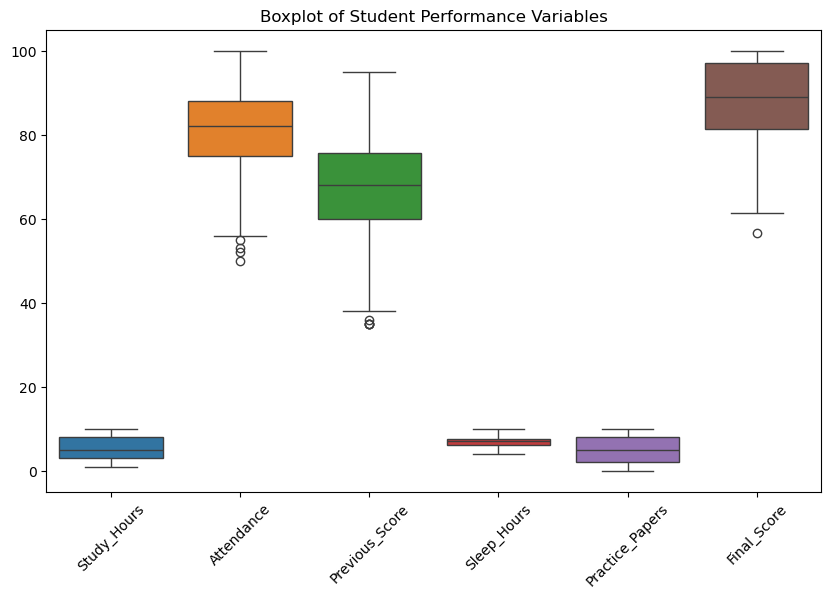

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Student Performance Variables")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Final Dataset

In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 650
Columns: 6
Missing values: 0
Duplicate rows: 0


In [15]:
##EDA Exploratory Data Analysis

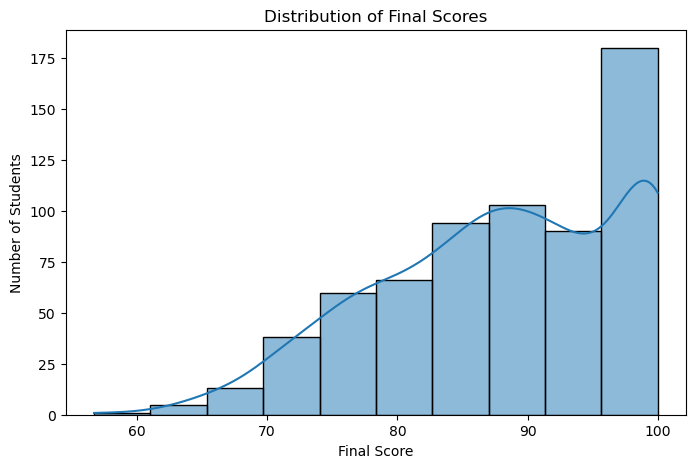

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Score"], bins=10, kde=True)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
##Study Hours vs Final Score

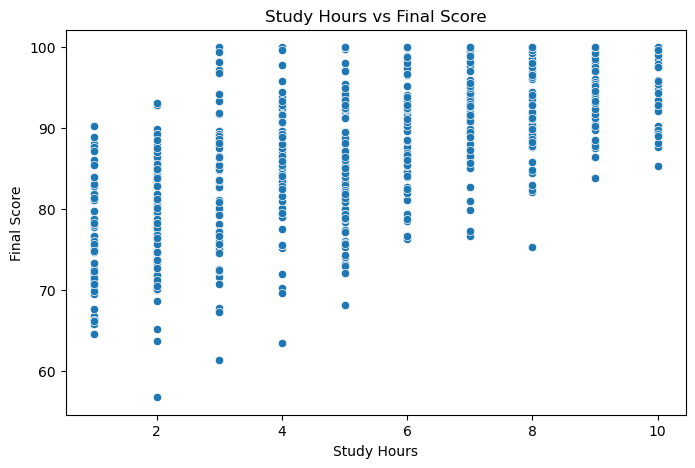

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Study_Hours", y="Final_Score", data=df)
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

In [ ]:
##Attendance vs Final Score

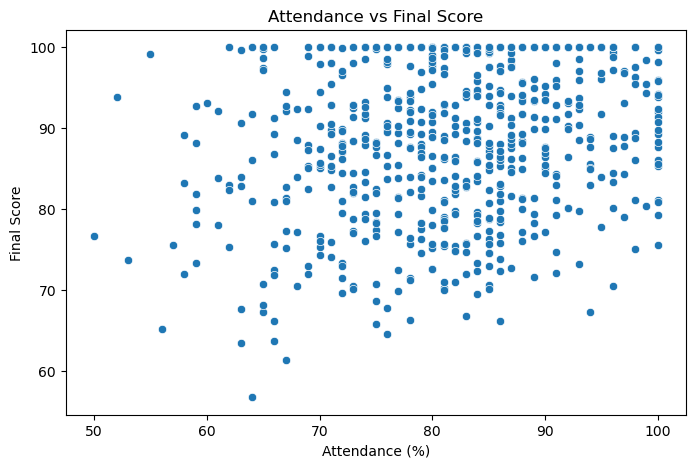

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Attendance", y="Final_Score", data=df)
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.show()

In [ ]:
##Previous Score vs Final Score

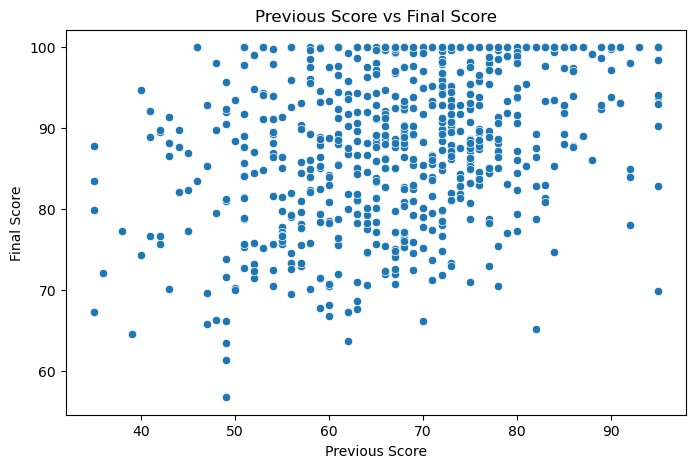

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Previous_Score", y="Final_Score", data=df)
plt.title("Previous Score vs Final Score")
plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.show()

In [ ]:
##Correlation Heatmap

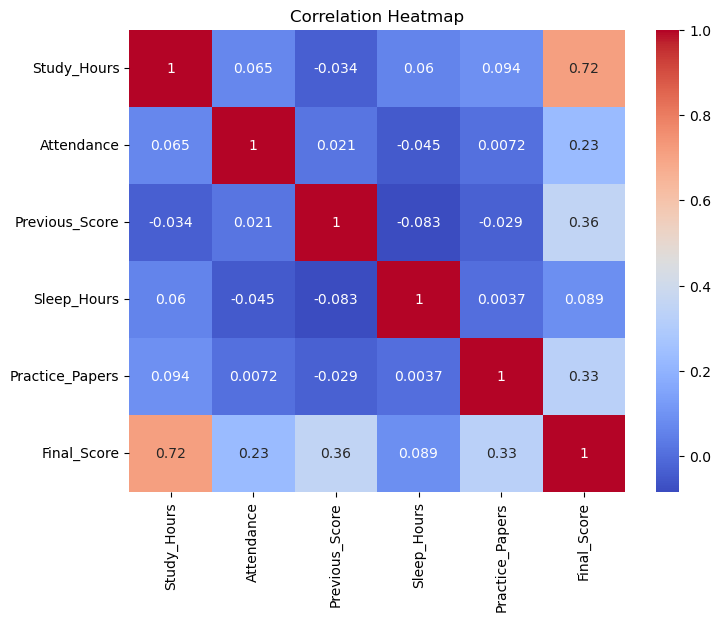

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
##Statistical measures

In [21]:
print("Mean Final Score:", df["Final_Score"].mean())
print("Median Final Score:", df["Final_Score"].median())
print("Standard Deviation:", df["Final_Score"].std())
print("Minimum Final Score:", df["Final_Score"].min())
print("Maximum Final Score:", df["Final_Score"].max())

Mean Final Score: 88.10415384615384
Median Final Score: 88.9
Standard Deviation: 9.487060264224876
Minimum Final Score: 56.7
Maximum Final Score: 100.0


In [22]:
X = df.drop("Final_Score", axis=1)
y = df["Final_Score"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (520, 5)
Testing data: (130, 5)


In [25]:
##Linear regression model

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual: [ 70.7  84.6  87.7  88.6  76.   99.1  76.3  84.  100.  100. ]
Predicted: [ 78.69619475  87.46827702  82.41099349  88.42938329  84.9114131
 100.43931454  81.65484104  83.94794967 102.53946372  99.14469182]


In [29]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Variable,Coefficient
0,Study_Hours,2.258118
1,Attendance,0.171570
2,Previous_Score,0.307327
3,Sleep_Hours,0.734172
4,Practice_Papers,0.810408


In [30]:
print("Intercept:", model.intercept_)

Intercept: 31.86867314029311


In [35]:
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

,Variable,Coefficient,Absolute_Coefficient
0,Study_Hours,2.258118,2.258118
4,Practice_Papers,0.810408,0.810408
3,Sleep_Hours,0.734172,0.734172
2,Previous_Score,0.307327,0.307327
1,Attendance,0.171570,0.171570


In [ ]:
## Interpretation

Linear Regression was used to predict the Final Score of students.

The model uses Study Hours, Attendance, Previous Score, Sleep Hours, and Practice Papers as input variables.

The coefficients show the relationship between each input variable and the predicted Final Score. A positive coefficient indicates a positive relationship, while a negative coefficient indicates a negative relationship.

The coefficient values can be used to compare the relative effect of the input variables on the predicted Final Score, while keeping the other variables constant.

In [ ]:
## Conclusion

This project used Linear Regression to predict student final performance based on Study Hours, Attendance, Previous Score, Sleep Hours, and Practice Papers.

The analysis helped identify the relationship between these factors and student performance. The project also demonstrated the use of data preprocessing, exploratory data analysis, statistical measures, and supervised machine learning using Python.

## Limitations

- The dataset contains a limited number of variables.
- Other factors may also affect student performance.
- The model predictions may not always be accurate.
- The dataset may not represent all students or educational environments.